In [4]:
import pandas as pd
import datetime as dt

# 1. Load the raw dataset
df = pd.read_csv('./amazon_sales_dataset/Amazon.csv')

# 2. Convert OrderDate to proper Datetime objects
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# 3. Filter out invalid orders (Cancelled and Returned)
# We use the tilde (~) operator to negate the condition
valid_statuses = ['Cancelled', 'Returned']
clean_df = df[~df['OrderStatus'].isin(valid_statuses)].copy()

# Optional: Verify no negative monetary values exist
assert (clean_df['TotalAmount'] > 0).all(), "Warning: Negative sales found!"

# 4. Establish a Snapshot Date for Recency (Latest date in data + 1 day)
snapshot_date = clean_df['OrderDate'].max() + dt.timedelta(days=1)

# 5. Aggregate the RFM metrics
rfm = clean_df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'OrderID': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                    # Monetary
}).reset_index()

# 6. Rename columns for extreme clarity
rfm.rename(columns={
    'OrderDate': 'Recency',
    'OrderID': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# 7. View the final, scientifically sound RFM table
print(rfm.head())

# Save your final data ready for clustering algorithms
rfm.to_csv('RFM_Metrics_Final.csv', index=False)

   CustomerID  Recency  Frequency  Monetary
0  CUST000002     1063          2   1112.67
1  CUST000003     1463          1   1116.91
2  CUST000004      196          3   2660.06
3  CUST000005      640          1   1089.56
4  CUST000006      249          3   2793.37


In [6]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

def score_frequency(x):
    if x <= 1:
        return 1
    elif x == 2:
        return 2
    elif x == 3:
        return 3
    else:
        return 4

rfm['F_Score'] = rfm['Frequency'].apply(score_frequency)

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Segment', 'RFM_Score']].head())

   CustomerID  Recency  Frequency  Monetary RFM_Segment  RFM_Score
0  CUST000002     1063          2   1112.67         222          6
1  CUST000003     1463          1   1116.91         112          4
2  CUST000004      196          3   2660.06         434         11
3  CUST000005      640          1   1089.56         312          6
4  CUST000006      249          3   2793.37         434         11


In [7]:
def assign_segment(score):
    if score >= 11:
        return 'Champions'
    elif score >= 9:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

# 2. Apply this function to create a new column
rfm['Customer_Profile'] = rfm['RFM_Score'].apply(assign_segment)

# 3. Let's see how many customers fall into each group!
print("--- Number of Customers per Profile ---")
print(rfm['Customer_Profile'].value_counts())

# 4. Let's look at the average behavior of each group
print("\n--- Average Behavior per Profile ---")
print(rfm.groupby('Customer_Profile')[['Recency', 'Frequency', 'Monetary']].mean().round(1).sort_values('Monetary', ascending=False))


--- Number of Customers per Profile ---
Customer_Profile
Champions              10891
Potential Loyalists     9015
Loyal Customers         8326
At Risk                 8169
Lost                    6003
Name: count, dtype: int64

--- Average Behavior per Profile ---
                     Recency  Frequency  Monetary
Customer_Profile                                 
Champions              258.1        3.7    3796.5
Loyal Customers        446.8        2.5    2320.0
Potential Loyalists    607.8        1.8    1549.0
At Risk                907.5        1.3    1048.4
Lost                  1313.4        1.0     499.8


C:\Users\ramak\AppData\Local\Temp\ipykernel_3552\4282172911.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='OrderStatus', ax=axes[0, 0],
C:\Users\ramak\AppData\Local\Temp\ipykernel_3552\4282172911.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[1, 1], palette='magma')


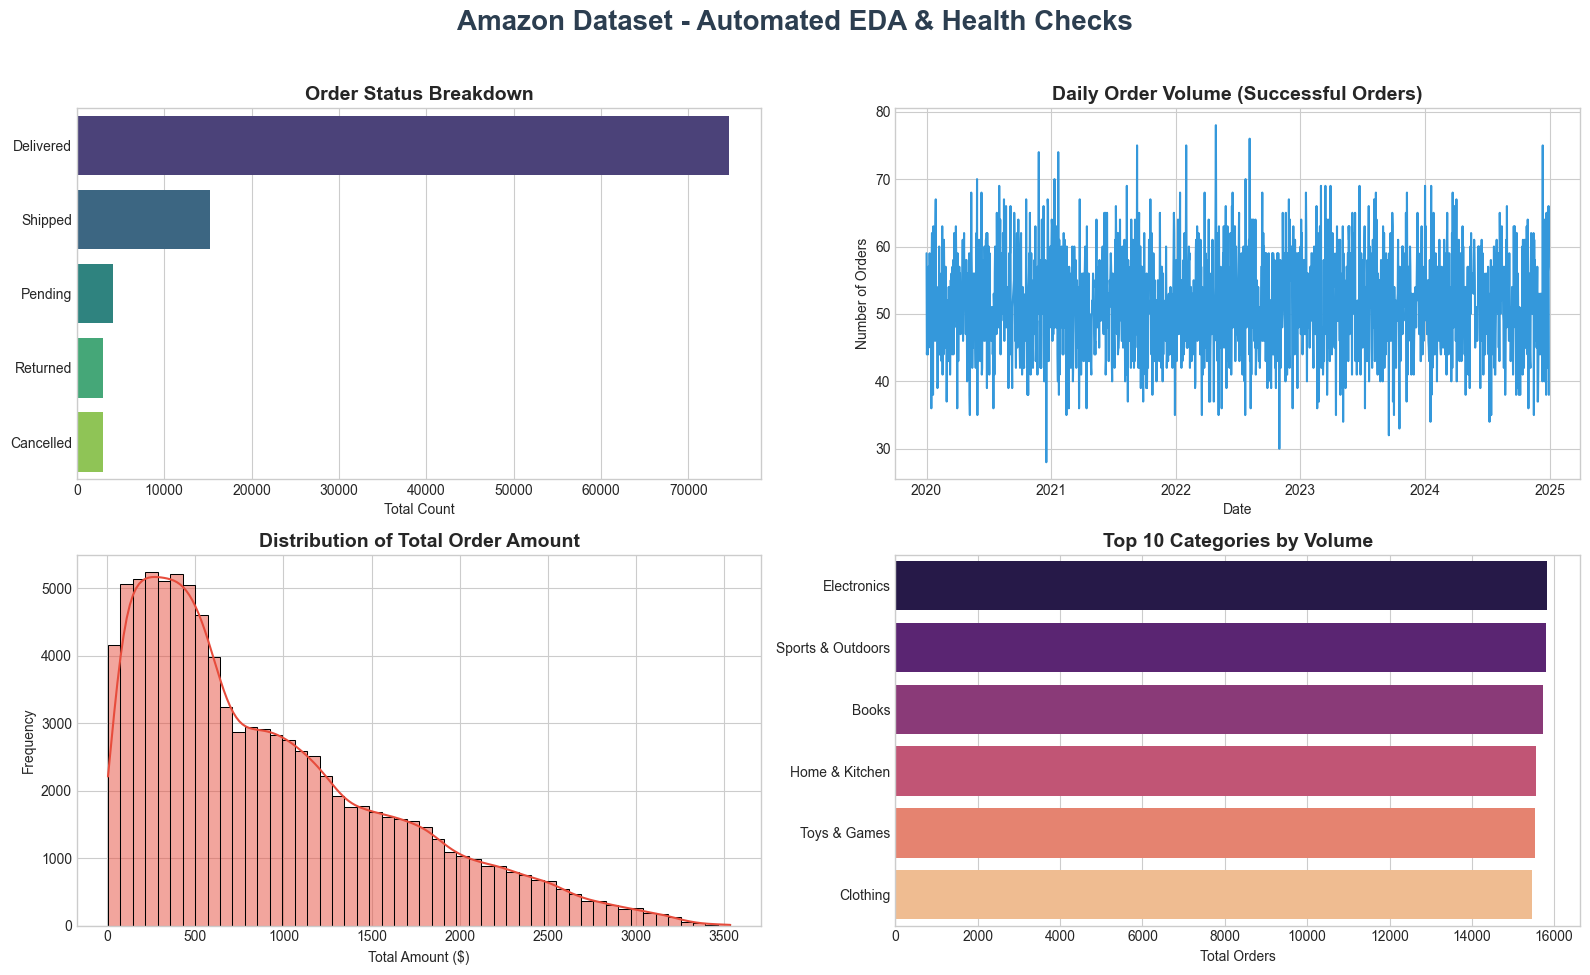

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# Initialize a 2x2 grid of plots (16 inches wide, 10 inches tall)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Add a master title to the entire dashboard
fig.suptitle('Amazon Dataset - Automated EDA & Health Checks', 
             fontsize=20, fontweight='bold', color='#2c3e50', y=0.97)

# ---------------------------------------------------------
# 3. PLOT A: Order Status Breakdown (Top-Left)
# ---------------------------------------------------------
# Visualizes the raw volume of successful vs failed deliveries
sns.countplot(data=df, y='OrderStatus', ax=axes[0, 0], 
              palette='viridis', order=df['OrderStatus'].value_counts().index)
axes[0, 0].set_title('Order Status Breakdown', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Count')
axes[0, 0].set_ylabel('')

# ---------------------------------------------------------
# 4. PLOT B: Daily Order Volume Time Series (Top-Right)
# ---------------------------------------------------------
# Maps continuous engagement over time
daily_orders = clean_df.groupby('OrderDate').size()
axes[0, 1].plot(daily_orders.index, daily_orders.values, color='#3498db', linewidth=1.5)
axes[0, 1].set_title('Daily Order Volume (Successful Orders)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Number of Orders')
axes[0, 1].set_xlabel('Date')

# ---------------------------------------------------------
# 5. PLOT C: Total Amount Distribution (Bottom-Left)
# ---------------------------------------------------------
# Density curve identifying the core monetary spread of purchases
sns.histplot(clean_df['TotalAmount'], bins=50, ax=axes[1, 0], color='#e74c3c', kde=True)
axes[1, 0].set_title('Distribution of Total Order Amount', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Total Amount ($)')
axes[1, 0].set_ylabel('Frequency')

# ---------------------------------------------------------
# 6. PLOT D: Top 10 Categories by Volume (Bottom-Right)
# ---------------------------------------------------------
# Horizontal bar chart revealing leading drivers of frequency
top_cats = clean_df['Category'].value_counts().nlargest(10)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Top 10 Categories by Volume', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Total Orders')
axes[1, 1].set_ylabel('')

# ---------------------------------------------------------
# 7. FINAL RENDER
# ---------------------------------------------------------
# Adjust spacing so labels don't overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the dashboard as a high-resolution PNG file


# Display the plot if running in a Jupyter Notebook / IDE
plt.show()

In [9]:
rfm.to_csv('amazon_rfm_segments.csv', index=False)